In [232]:
import tensorflow as tf
import os

In [233]:
gpus = tf.config.experimental.list_physical_devices('CPU')

In [234]:
gpus

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [235]:
#removing dodgy images 
import cv2
import imghdr


In [236]:
data_dir ="data"

In [237]:
image_exts = ['jpeg','jpg','bmp','png']

In [238]:
image_exts[2]

'bmp'

In [239]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path = os.path.join(data_dir,image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext lists {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with Image {}'.format(image_path))
            #removed dodgy images
            

In [127]:
#load data
import numpy as np
from matplotlib import pyplot as plt

In [128]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 156 files belonging to 2 classes.


In [129]:
# get another batch from the iterator
data_iterator = data.as_numpy_iterator()

In [130]:
batch = data_iterator.next()

In [131]:
batch[0].shape

(32, 256, 256, 3)

In [132]:
#class 1 = sad ppl
#c class 0 = happy ppl
batch[1]

array([1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0], dtype=int32)

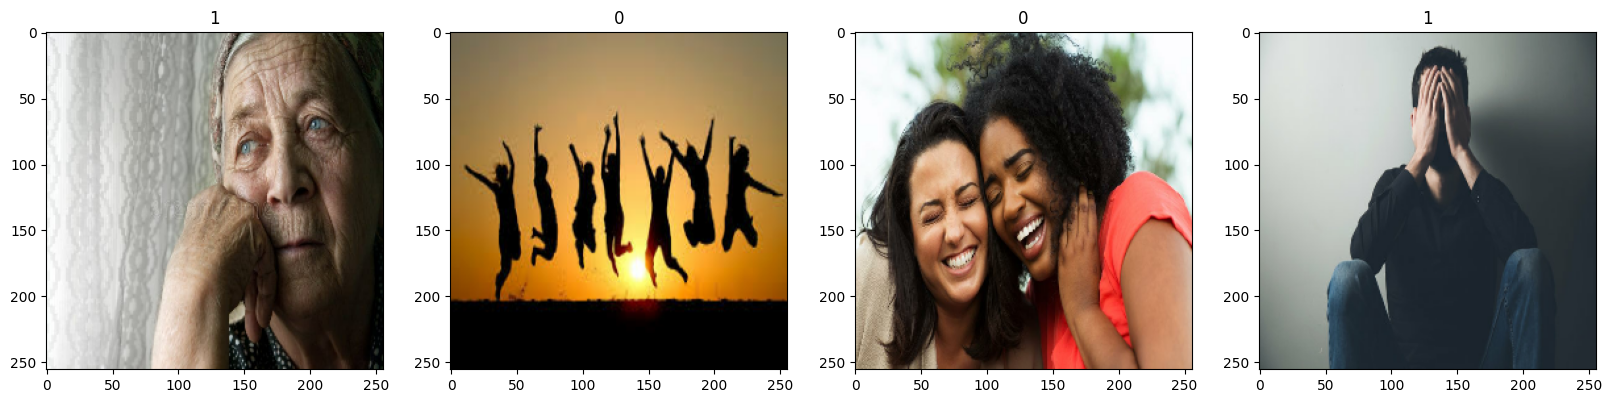

In [133]:
fig,ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [134]:
# step Preprcess data
#scaling data
data = data.map(lambda x,y: (x/255,y))

In [135]:
scaled_iterator = data.as_numpy_iterator()

In [136]:
batch = scaled_iterator.next()

In [137]:
batch[0].min()

np.float32(0.0)

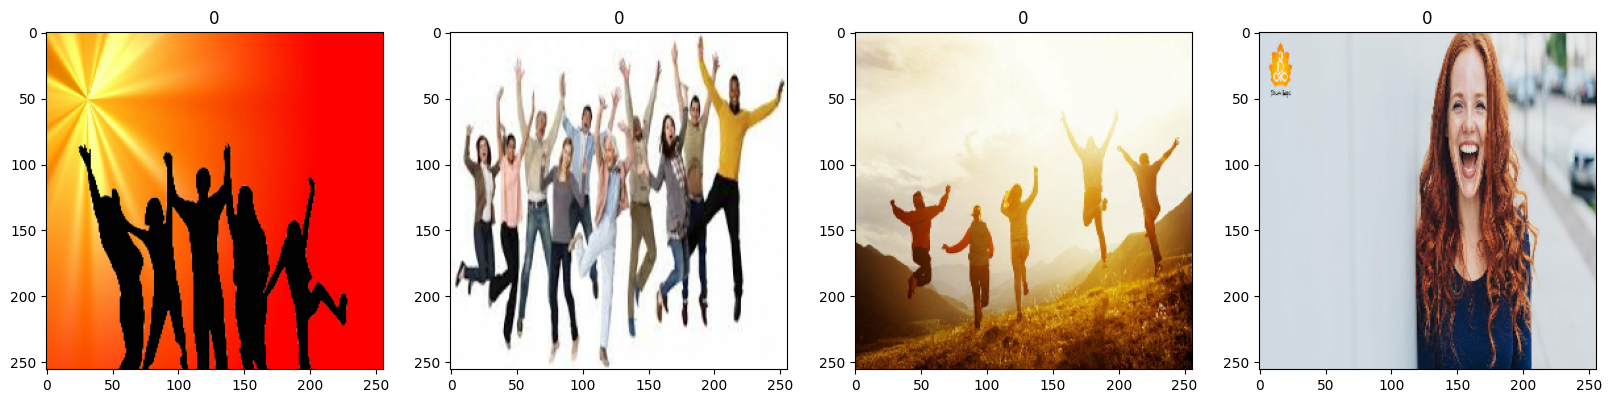

In [138]:
fig,ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img)
    ax[idx].title.set_text(batch[1][idx])

In [139]:
len(data)

5

In [140]:
train_size = int(len(data)*0.7)
val_size = int(len(data)*0.2)
test_size = len(data) - train_size - val_size

In [141]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

In [142]:
train_size+val_size+test_size

5

In [143]:
len(test)

1

In [207]:
#deep model
#building deep learning model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D,Dense,Flatten


In [208]:
model = Sequential()

In [209]:
model.add(Conv2D(16,(3,3),1,activation ='relu', input_shape =(255,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16,(3,3),1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [210]:
model.compile('adam', loss = tf.losses.BinaryCrossentropy(), metrics = ['accuracy'])

In [211]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 253, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 126, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 124, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [212]:
#train
logdir ='logs'


In [213]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = logdir)

In [214]:
hist = model.fit(train, epochs = 20, validation_data = val, callbacks = [tensorboard_callback])

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 613ms/step - accuracy: 0.4688 - loss: 0.7158 - val_accuracy: 0.8125 - val_loss: 0.4693
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 531ms/step - accuracy: 0.7188 - loss: 0.5141 - val_accuracy: 0.8438 - val_loss: 0.4061
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 931ms/step - accuracy: 0.8542 - loss: 0.4012 - val_accuracy: 0.7188 - val_loss: 0.6157
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 775ms/step - accuracy: 0.8542 - loss: 0.3321 - val_accuracy: 0.9375 - val_loss: 0.2079
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 719ms/step - accuracy: 0.9271 - loss: 0.2464 - val_accuracy: 0.9062 - val_loss: 0.2072
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 722ms/step - accuracy: 0.9167 - loss: 0.1902 - val_accuracy: 1.0000 - val_loss: 0.1398
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 591ms/step - accuracy: 0.9688 - loss: 0.1454 - val_accuracy: 0.8125 - val_loss: 0.2654
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 532ms/step - accuracy: 0.9479 - loss: 0.1545 - val_accuracy: 0.9688 - val_loss:

In [215]:
#plot performance

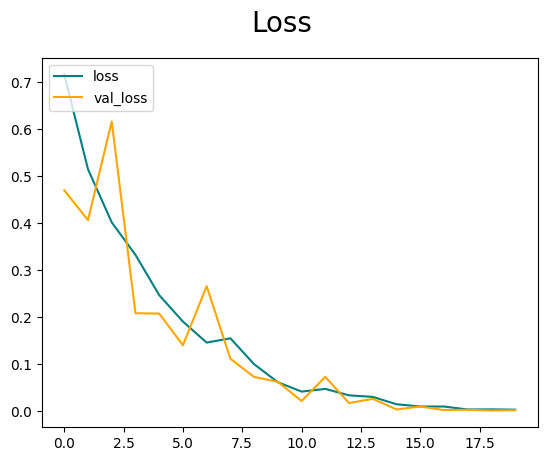

In [216]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'teal', label = 'loss')
plt.plot(hist.history['val_loss'],color = 'orange', label ='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc = "upper left")
plt.show()

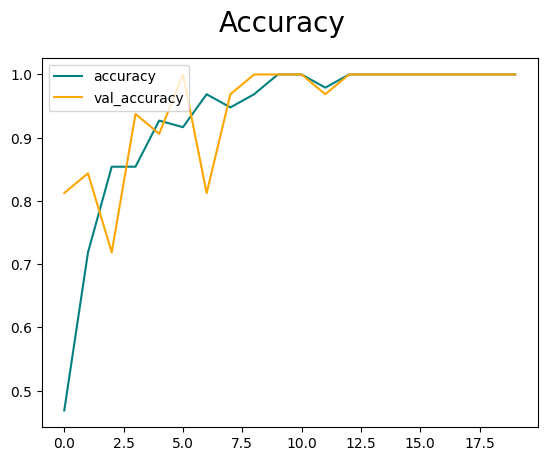

In [217]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'teal', label = 'accuracy')
plt.plot(hist.history['val_accuracy'],color = 'orange', label ='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc = "upper left")
plt.show()

In [218]:
#evaluate performance
from tensorflow.keras.metrics import Precision,Recall, BinaryAccuracy


In [219]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [220]:
len(test)

1

In [221]:
for batch in test.as_numpy_iterator():
    x,y = batch
    yhat = model.predict(x)
    pre.update_state(y,yhat)
    re.update_state(y,yhat)
    acc.update_state(y,yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


In [222]:
print(f'Precision:{pre.result().numpy()}, '
      f'Recall:{re.result().numpy()}, '
      f'Accuracy:{acc.result().numpy()}')

Precision:1.0, Recall:1.0, Accuracy:1.0


In [223]:
#test
import cv2


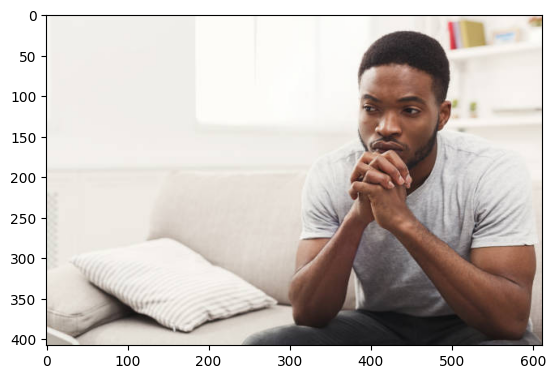

In [224]:
img = cv2.imread("sadman.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

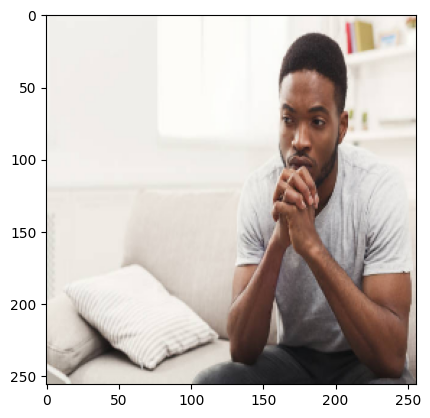

In [225]:
resize = tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()


In [203]:
np.expand_dims(resize,0).shape

(1, 256, 256, 3)

In [226]:
yhat = model.predict(np.expand_dims(resize/255,0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


In [229]:
yhat


array([[0.9919982]], dtype=float32)

In [230]:
if yhat > 0.5:
    print( f'Predicted class is sad')
else:
    print(f'Predicted class is Happy')

Predicted class is sad


In [231]:

model.save("models/emotion_model.h5")

In [1]:
import keras
print(keras.__version__)

3.12.1


In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0
